In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
np.random.seed(32)

In [3]:
seg1 = np.random.normal(loc = [30,25], scale=[6,9], size=(100,2))
seg2 = np.random.normal(loc = [80,20], scale=[7,9], size=(100,2))
seg3 = np.random.normal(loc = [90,85], scale=[7,7], size=(100,2))
seg4 = np.random.normal(loc = [30,75], scale=[6,9], size=(100,2))

In [4]:
data = np.vstack([seg1, seg2, seg3, seg4])
df = pd.DataFrame(data, columns=['Income','Spend'])
df.describe()

,Income,Spend
count,400.000000,400.000000
mean,57.420532,52.018623
std,27.869502,31.067724
min,15.789026,-1.099908
25%,30.790223,21.885810
50%,56.792353,46.494337
75%,83.715011,82.212672
max,104.862092,103.926797


In [5]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(df)

In [6]:
df.head()

,Income,Spend
0,27.906633,33.853331
1,33.485537,25.632560
2,34.665196,30.237629
3,38.830743,39.968629
4,28.432937,18.801909


In [7]:
X_Scaled

array([[-1.06032969, -0.58543204],
       [-0.85989947, -0.8503715 ],
       [-0.8175185 , -0.70195909],
       [-0.66786518, -0.38834787],
       [-1.04142145, -1.07051011],
       [-1.13491921, -0.307933  ],
       [-0.59594947, -0.73840271],
       [-1.10902819, -0.83763934],
       [-0.65885693, -0.76891101],
       [-1.00429278, -0.60479281],
       [-0.87612624, -1.1072291 ],
       [-0.90123757, -0.99401911],
       [-0.97658133, -1.02389494],
       [-1.09512285, -1.12840701],
       [-0.75067546, -0.67543857],
       [-1.21519194, -0.51745924],
       [-0.2600449 , -1.11215486],
       [-1.05848751, -1.409841  ],
       [-0.98494503, -0.76878262],
       [-0.65714796, -1.0681309 ],
       [-0.78291594, -1.06840372],
       [-1.02847089, -0.8758303 ],
       [-1.37052249, -1.11780706],
       [-1.33611741, -0.59027757],
       [-0.97367292, -0.78672572],
       [-0.97166203, -1.18927266],
       [-0.95698491, -0.92451516],
       [-1.2741295 , -0.9647404 ],
       [-0.66515499,

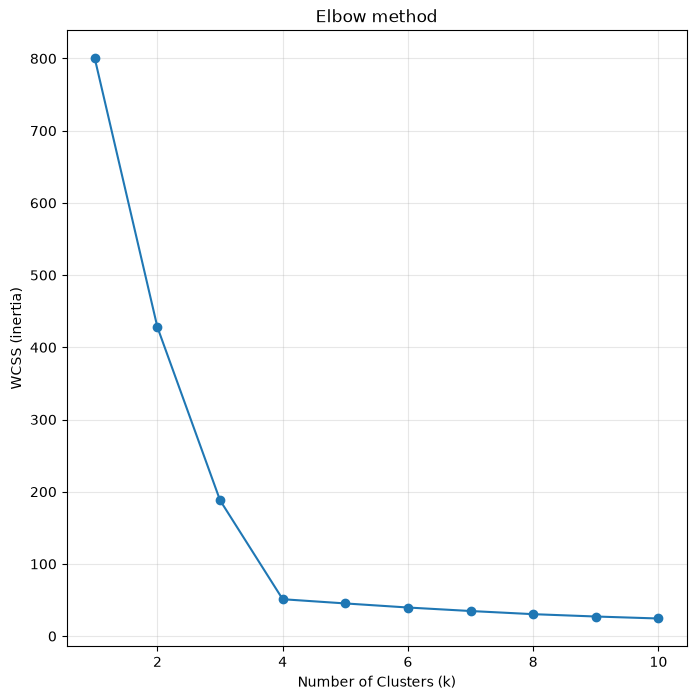

In [8]:
# Elbow Method - WCSS

wcss_values = []
k_range = range(1,11)

for k in k_range:
    km = KMeans(n_clusters=k, init = 'k-means++', n_init=10, random_state=32)
    km.fit(X_Scaled)
    wcss_values.append(km.inertia_)

plt.figure(figsize=(8,8))
plt.plot(k_range, wcss_values, marker='o')
plt.title("Elbow method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (inertia)")
plt.grid(alpha = 0.3)
plt.show()

In [9]:
K = 4
model = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=32)
df['Cluster'] =  model.fit_predict(X_Scaled)

centroid_og = scaler.inverse_transform(model.cluster_centers_)

In [14]:
df

,Income,Spend,Cluster
0,27.906633,33.853331,3
1,33.485537,25.632560,3
2,34.665196,30.237629,3
3,38.830743,39.968629,3
4,28.432937,18.801909,3
...,...,...,...
395,23.444617,91.666508,0
396,30.983350,90.041045,0
397,25.685907,87.845872,0
398,35.322804,87.581959,0


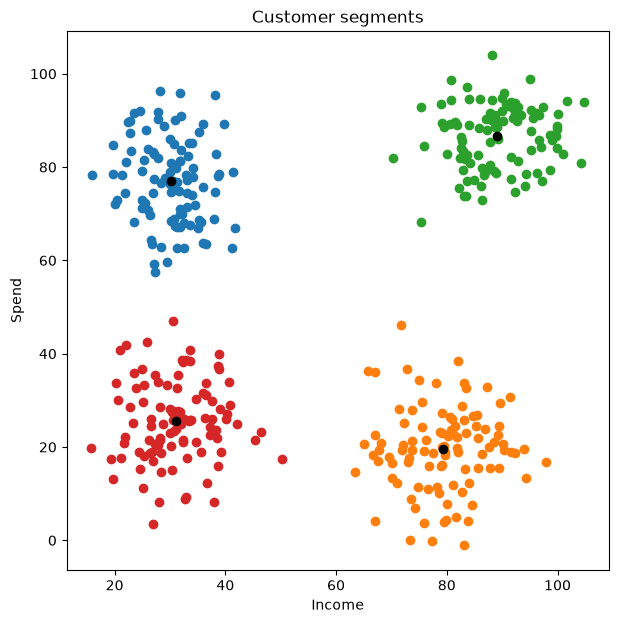

In [12]:


plt.figure(figsize=(7,7))
for cluster_id in range(K):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Income'], cluster_data['Spend'])

plt.scatter(centroid_og[:,0], centroid_og[:,1], color="black")

plt.title("Customer segments")
plt.xlabel("Income")
plt.ylabel("Spend")
plt.show()